<a href="https://colab.research.google.com/github/araoclaudio2-create/Assignment-AI-2/blob/main/Assignment_9_Intro_to_Ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


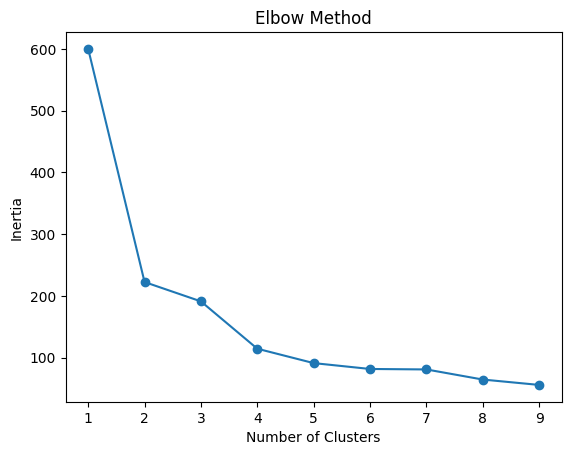

K-Means Silhouette Score: 0.4798814508199817
Hierarchical Silhouette Score: 0.4466890410285909


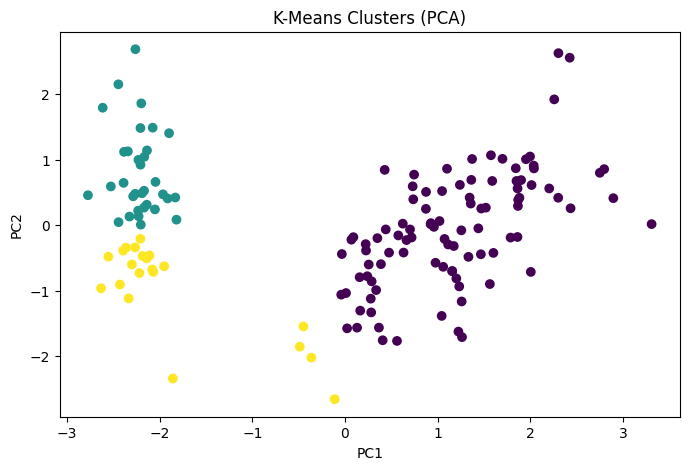

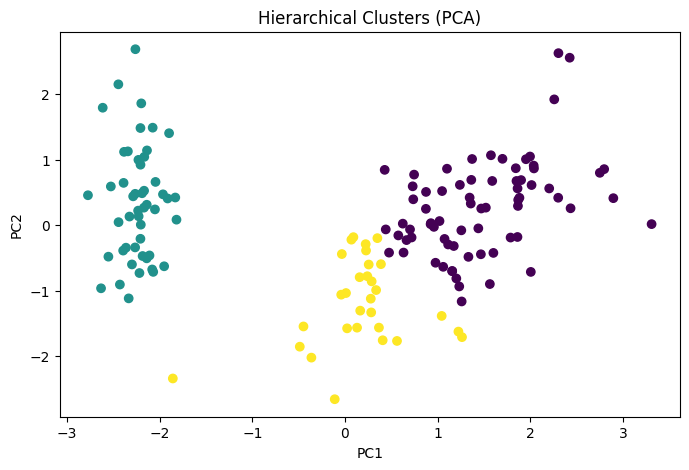

Summary:
K-Means Silhouette Score: 0.4798814508199817
Hierarchical Silhouette Score: 0.4466890410285909


In [1]:

# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 2. Load Dataset
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)

print(df.head())

# 3. Preprocessing
# No missing values in Iris, but we standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. K-Means Clustering
# Elbow Method
inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Apply KMeans (k=3)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Silhouette Score
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print("K-Means Silhouette Score:", kmeans_silhouette)

# 5. Hierarchical Clustering

agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X_scaled)

agg_silhouette = silhouette_score(X_scaled, agg_labels)
print("Hierarchical Silhouette Score:", agg_silhouette)

# 6. PCA (Dimensionality Reduction)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot KMeans Clusters
plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("K-Means Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Plot Hierarchical Clusters
plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=agg_labels)
plt.title("Hierarchical Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 7. Summary
print("Summary:")
print(f"K-Means Silhouette Score: {kmeans_silhouette}")
print(f"Hierarchical Silhouette Score: {agg_silhouette}")